<a href="https://colab.research.google.com/github/rounak393/clab/blob/main/attention_ttv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import PIL



In [2]:

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

class MaskTransform:
    def __call__(self, target):
        target = target.resize((128, 128), PIL.Image.NEAREST)
        target = torch.as_tensor(np.array(target), dtype=torch.long)
        return target - 1


In [4]:
dataset = datasets.OxfordIIITPet(
    root="./data", split="trainval", target_types="segmentation",
    download=True, transform=transform, target_transform=MaskTransform()
)

100%|██████████| 792M/792M [00:35<00:00, 22.3MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.8MB/s]


In [5]:
small_dataset = Subset(dataset, range(200))
train_sub, val_sub, test_sub = random_split(small_dataset, [180, 10, 10])

train_loader = DataLoader(train_sub, batch_size=8, shuffle=True)
val_loader = DataLoader(val_sub, batch_size=8, shuffle=False)
test_loader = DataLoader(test_sub, batch_size=8, shuffle=False)




In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()
        # Encoder
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # Decoder + Attention Gates
        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.att1 = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.conv1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.att2 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.conv2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.att3 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.conv3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att4 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.conv4 = DoubleConv(128, 64)

        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        g1 = self.up1(x5)
        x4_att = self.att1(g=g1, x=x4)
        d1 = self.conv1(torch.cat([x4_att, g1], dim=1))

        g2 = self.up2(d1)
        x3_att = self.att2(g=g2, x=x3)
        d2 = self.conv2(torch.cat([x3_att, g2], dim=1))

        g3 = self.up3(d2)
        x2_att = self.att3(g=g3, x=x2)
        d3 = self.conv3(torch.cat([x2_att, g3], dim=1))

        g4 = self.up4(d3)
        x1_att = self.att4(g=g4, x=x1)
        d4 = self.conv4(torch.cat([x1_att, g4], dim=1))

        return self.outc(d4)


In [7]:
def calculate_iou(preds, labels, num_classes=3):
    ious = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (labels == cls)
        intersection = (pred_inds & target_inds).float().sum().item()
        union = (pred_inds | target_inds).float().sum().item()
        if union > 0:
            ious.append(intersection / union)
    return np.mean(ious) if ious else 0.0

model = AttentionUNet(n_channels=3, n_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epochs = 15
for epoch in range(epochs):
    model.train()
    train_loss, train_iou = 0, 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_iou += calculate_iou(torch.argmax(preds, dim=1), masks)

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss/len(train_loader):.3f} | Train mIoU: {train_iou/len(train_loader):.3f}")



Epoch 01 | Train Loss: 0.906 | Train mIoU: 0.363
Epoch 02 | Train Loss: 0.704 | Train mIoU: 0.438
Epoch 03 | Train Loss: 0.638 | Train mIoU: 0.475
Epoch 04 | Train Loss: 0.626 | Train mIoU: 0.480
Epoch 05 | Train Loss: 0.598 | Train mIoU: 0.498
Epoch 06 | Train Loss: 0.560 | Train mIoU: 0.520
Epoch 07 | Train Loss: 0.550 | Train mIoU: 0.532
Epoch 08 | Train Loss: 0.549 | Train mIoU: 0.525
Epoch 09 | Train Loss: 0.509 | Train mIoU: 0.553
Epoch 10 | Train Loss: 0.511 | Train mIoU: 0.554
Epoch 11 | Train Loss: 0.501 | Train mIoU: 0.553
Epoch 12 | Train Loss: 0.465 | Train mIoU: 0.586
Epoch 13 | Train Loss: 0.475 | Train mIoU: 0.574
Epoch 14 | Train Loss: 0.450 | Train mIoU: 0.585
Epoch 15 | Train Loss: 0.427 | Train mIoU: 0.609


------------------------------
final mIoU: 0.5854
------------------------------


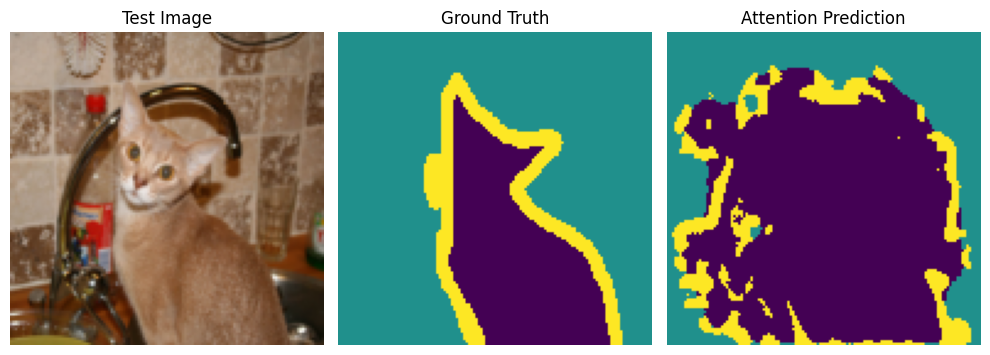

In [8]:
model.eval()
all_val_ious = []
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        output = model(images)
        pred_labels = torch.argmax(output, dim=1)
        all_val_ious.append(calculate_iou(pred_labels, masks))

final_val_iou = np.mean(all_val_ious)
print("-" * 30)
print(f"final mIoU: {final_val_iou:.4f}")
print("-" * 30)


with torch.no_grad():
    images, masks = next(iter(test_loader)) # Show results from the Test Set
    images, masks = images.to(device), masks.to(device)
    preds = torch.argmax(model(images), dim=1)

    plt.figure(figsize=(10, 4))
    plt.subplot(1,3,1); plt.imshow(images[0].cpu().permute(1,2,0)); plt.title("Test Image"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(masks[0].cpu()); plt.title("Ground Truth"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(preds[0].cpu()); plt.title("Attention Prediction"); plt.axis('off')
    plt.tight_layout()
